NEHA.N.K | 24BAD078
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
Mean Squared Error: 210.19254305293808
Root Mean Squared Error: 14.498018590584648
R2 Score: 0.019471430077149465

Regression Coefficients:

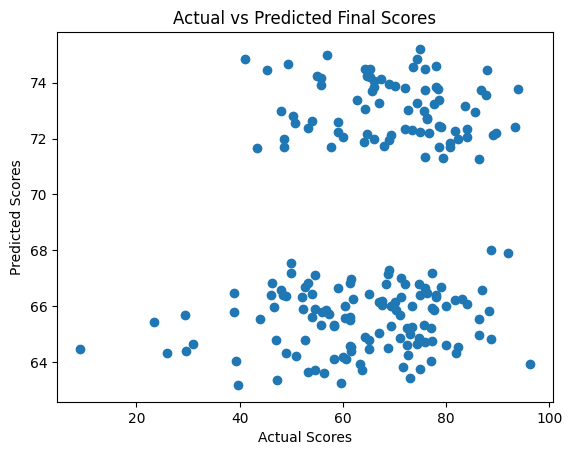

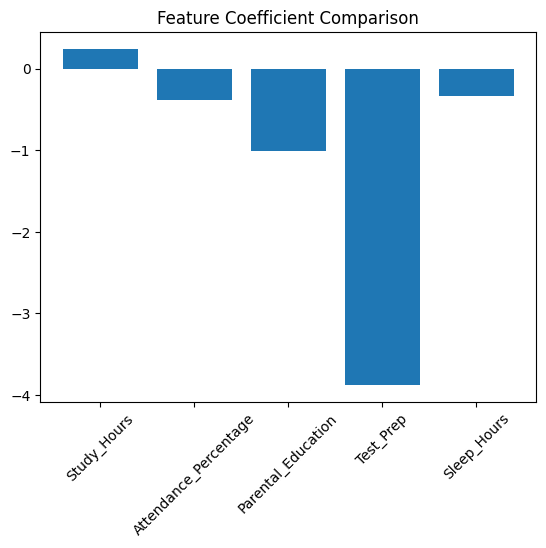

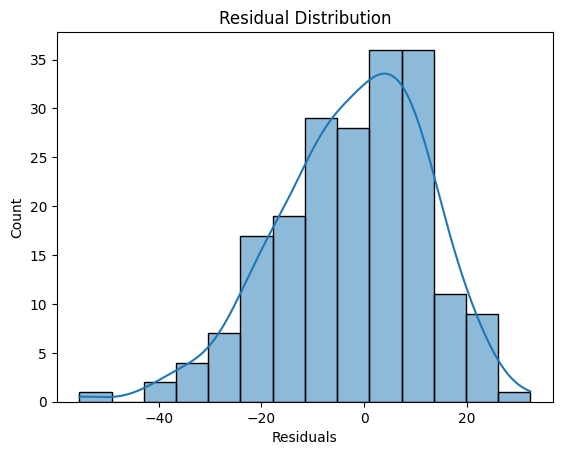

In [2]:
# Multilinear Regression
# NEHA.N.K
# Roll No: 24BAD078

print("NEHA.N.K | 24BAD078")


# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Loading the dataset
df = pd.read_csv("StudentsPerformance.csv")

# Display first few rows
print(df.head())


# Creating the target variable: Final Exam Score
df["Final_Score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3


# Simulating additional features for the lab scenario
# (Since Kaggle dataset does not contain these columns)
np.random.seed(42)

df["Study_Hours"] = np.random.randint(1, 6, size=len(df))
df["Attendance_Percentage"] = np.random.randint(60, 100, size=len(df))
df["Sleep_Hours"] = np.random.randint(4, 9, size=len(df))


# Encoding categorical variables
le = LabelEncoder()

df["Parental_Education"] = le.fit_transform(df["parental level of education"])
df["Test_Prep"] = le.fit_transform(df["test preparation course"])


# Selecting input features
X = df[[
    "Study_Hours",
    "Attendance_Percentage",
    "Parental_Education",
    "Test_Prep",
    "Sleep_Hours"
]]

# Selecting target variable
y = df["Final_Score"]


# Handling missing values using mean imputation
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)


# Applying feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# Training the Multilinear Regression model
model = LinearRegression()
model.fit(X_train, y_train)


# Predicting on test data
y_pred = model.predict(X_test)


# Evaluating model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)


# Creating a dataframe for regression coefficients
coeff_df = pd.DataFrame({
    "Feature": [
        "Study_Hours",
        "Attendance_Percentage",
        "Parental_Education",
        "Test_Prep",
        "Sleep_Hours"
    ],
    "Coefficient": model.coef_
})

print("\nRegression Coefficients:")
print(coeff_df)


# Feature elimination example (removing Sleep_Hours)
X_reduced = df[[
    "Study_Hours",
    "Attendance_Percentage",
    "Parental_Education",
    "Test_Prep"
]]

X_reduced = scaler.fit_transform(X_reduced)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

model_reduced = LinearRegression()
model_reduced.fit(X_train_r, y_train_r)

print("\nR2 Score after Feature Elimination:",
      r2_score(y_test_r, model_reduced.predict(X_test_r)))


# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_r2 = r2_score(y_test, ridge.predict(X_test))
print("\nRidge Regression R2 Score:", ridge_r2)


# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_r2 = r2_score(y_test, lasso.predict(X_test))
print("Lasso Regression R2 Score:", lasso_r2)


# ------------------ VISUALIZATIONS ------------------ #

# Plotting Actual vs Predicted values
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Final Scores")
plt.show()


# Plotting Coefficient Magnitude Comparison
plt.figure()
plt.bar(coeff_df["Feature"], coeff_df["Coefficient"])
plt.xticks(rotation=45)
plt.title("Feature Coefficient Comparison")
plt.show()


# Plotting Residual Distribution
residuals = y_test - y_pred

plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()



NEHA.N.K | 24BAD078

Degree: 2
Training MSE: 19.20461369197704
Testing MSE: 18.4169677960178
Testing RMSE: 4.291499481069269
Testing R2 Score: 0.639170114701331

Degree: 3
Training MSE: 19.143788034701597
Testing MSE: 18.460267222224637
Testing RMSE: 4.29654130926547
Testing R2 Score: 0.6383217814053859

Degree: 4
Training MSE: 19.12619134399978
Testing MSE: 18.268226874853195
Testing RMSE: 4.27413463461941
Testing R2 Score: 0.6420842844016574


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


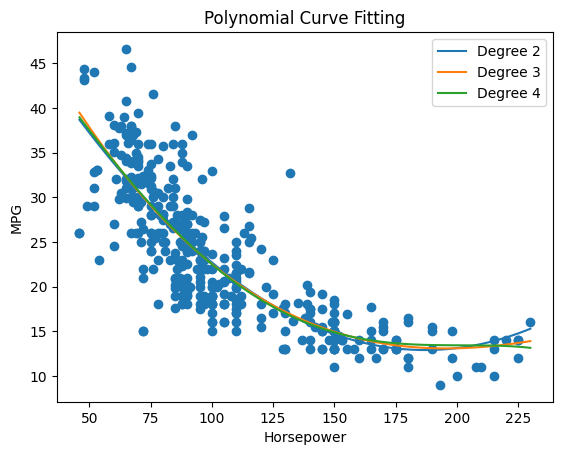

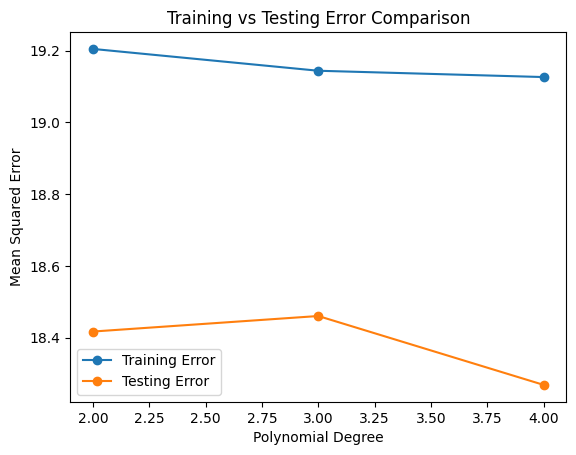

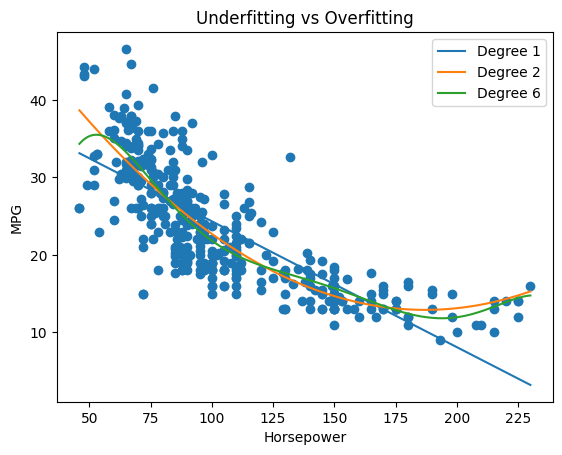


Ridge Regression (Degree 6)
MSE: 17.519416713268242
RMSE: 4.185620230416066
R2 Score: 0.656755162241472


In [1]:
# Polynomial Regression
# NEHA.N.K
# Roll No: 24BAD078

print("NEHA.N.K | 24BAD078")

# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Loading dataset
df = pd.read_csv("auto-mpg.csv")

# Cleaning horsepower column
df["horsepower"] = pd.to_numeric(df["horsepower"], errors='coerce')
df = df.dropna()

# Selecting independent and dependent variables
X = df[["horsepower"]]
y = df["mpg"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

degrees = [2, 3, 4]
train_errors = []
test_errors = []

# Training polynomial models
for degree in degrees:

    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

    print("\nDegree:", degree)
    print("Training MSE:", train_mse)
    print("Testing MSE:", test_mse)
    print("Testing RMSE:", np.sqrt(test_mse))
    print("Testing R2 Score:", r2_score(y_test, y_test_pred))

# Visualization 1: Polynomial Curve Fitting

X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)

plt.figure()

for degree in degrees:

    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    X_range_poly = poly.transform(X_range_scaled)
    y_range_pred = model.predict(X_range_poly)

    plt.plot(X_range, y_range_pred, label=f"Degree {degree}")

plt.scatter(X, y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Curve Fitting")
plt.legend()
plt.show()

# Visualization 2: Training vs Testing Error Comparison

plt.figure()
plt.plot(degrees, train_errors, marker='o', label="Training Error")
plt.plot(degrees, test_errors, marker='o', label="Testing Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training vs Testing Error Comparison")
plt.legend()
plt.show()

# Visualization 3: Underfitting vs Overfitting Demonstration

plt.figure()

for degree in [1, 2, 6]:   # 1 = underfit, 2 = good fit, 6 = overfit

    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_scaled)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    X_range_poly = poly.transform(X_range_scaled)
    y_range_pred = model.predict(X_range_poly)

    plt.plot(X_range, y_range_pred, label=f"Degree {degree}")

plt.scatter(X, y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Underfitting vs Overfitting")
plt.legend()
plt.show()

# Ridge Regression to Control Overfitting (Degree 6)

poly = PolynomialFeatures(degree=6)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

ridge_pred = ridge.predict(X_test_poly)

print("\nRidge Regression (Degree 6)")
print("MSE:", mean_squared_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2 Score:", r2_score(y_test, ridge_pred))
